In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import xarray
sys.path.append("../src/climate_trends/")

import load as ld
from Model_A import log_likelihood,log_probability,climate_model
import xarray as xr
import pandas as pd
from statsmodels.tsa.seasonal import STL
import emcee
import arviz as az

/opt/anaconda3/envs/eo/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [25]:
import Model_A
from importlib import reload
reload(Model_A)
from Model_A import log_likelihood,log_probability,climate_model
from Model_A import log_likelihood_harmonics,log_probability_harmonics,climate_model_harmonics

# Summary
In this notebook, I analyze the long-term warming trend of Paris over the period of 1950-2025 using the ERA5 near-surface air temperature (t2m) monthly data. I use annual averages of the monthly temperature data to study how the climate has evolved over the last seven decades.

The analysis is performed using a Bayesian parametric model. Since climate data contain strong seasonal variations and temporal correlations, I first remove the seasonal component using STL decomposition. I then model the residual temperature evolution using a linear trend with an AR(1) process to account for memory in the residuals. In a second approach, I directly model the seasonal signal within the Bayesian framework using harmonic components up to the fourth and fifth order. The warming rates obtained from both methods are consistent with each other.

I also investigate the trend in annual extreme temperatures, since one of the key signatures of climate change is the increasing frequency and intensity of extreme weather events.

From this analysis, I find that Paris has warmed at a rate of approximately $0.26 \pm 0.06^\circ\mathrm{C}$ per decade over 1950-2025. The warming trend in annual maximum temperatures is even stronger, reaching about $0.32 \pm 0.06^\circ\mathrm{C}$ per decade.

# Load the data [for Paris]

In [4]:
ds_p=ld.load_single_file("../data/raw/era5_paris_t2m.nc")
t2m_p = ds_p["t2m"].sel(latitude=48.75,longitude=2.25,method='nearest') -273.15

# Data processing
I take the paris monthly dataset and subtract the seasonality from it using STL decomposition. Then take the yearly  average of the temperature and time axis. Last, I normalize the the time axis for numerical stability.

In [ ]:
series = t2m_p.to_series().dropna()
series = series.sort_index()
#####
stl_p = STL(series, period=12, robust=True)  # monthly data 
result = stl_p.fit()
temp_trend=result.trend
temp_seasonal=result.seasonal

##### Subtract Seasonal Trend ######
removed_seasonal=t2m_p-temp_seasonal

##### Take annual average ##########
t2m_trend_1year = removed_seasonal.resample({"valid_time": "1YE"}).mean()
time_trend_1year=pd.to_datetime(t2m_trend_1year["valid_time"].values)
t2m_trend_1year_values=t2m_trend_1year.values
time_trend_1year_values=(time_trend_1year.year).values

### Normalize time axis ##############
time_mean = time_trend_1year_values.mean()
time_std  = time_trend_1year_values.std()
time_norm = (time_trend_1year_values - time_mean) / time_std


# Bayesian Code with AR(1) on Annual Average temperature

In [9]:
## Define the number of walkers and initial parameters
ndim = 4
nwalkers = 32

initial = np.array([
    t2m_trend_1year_values.mean(),   # beta0
    0.01,          # beta1
    0.5,           # psi
    2.0            # sigma
])

# Initialize walkers
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

## Run the Sampler

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(time_norm, t2m_trend_1year_values)
)

sampler.run_mcmc(pos, 10000, progress=True)

## Extract samples

samples = sampler.get_chain(
    discard=2000,
    thin=10,
    flat=True
)

## Parameter estimates from chain

labels = [
    "beta0",
    "beta1",
    "psi",
    "sigma"
]

print("\nPosterior parameter estimates:\n")

for i, label in enumerate(labels):

    q16, q50, q84 = np.percentile(
        samples[:, i],
        [16, 50, 84]
    )

    print(
        f"{label:8s} = "
        f"{q50:.4f} "
        f"(+{q84-q50:.4f}, -{q50-q16:.4f})"
    )

You must install the tqdm library to use progress indicators with emcee



Posterior parameter estimates:

beta0    = 10.9387 (+0.0979, -0.0944)
beta1    = 0.5606 (+0.0915, -0.0954)
psi      = 0.2521 (+0.1192, -0.1140)
sigma    = 0.6171 (+0.0557, -0.0488)


## Convergence checks

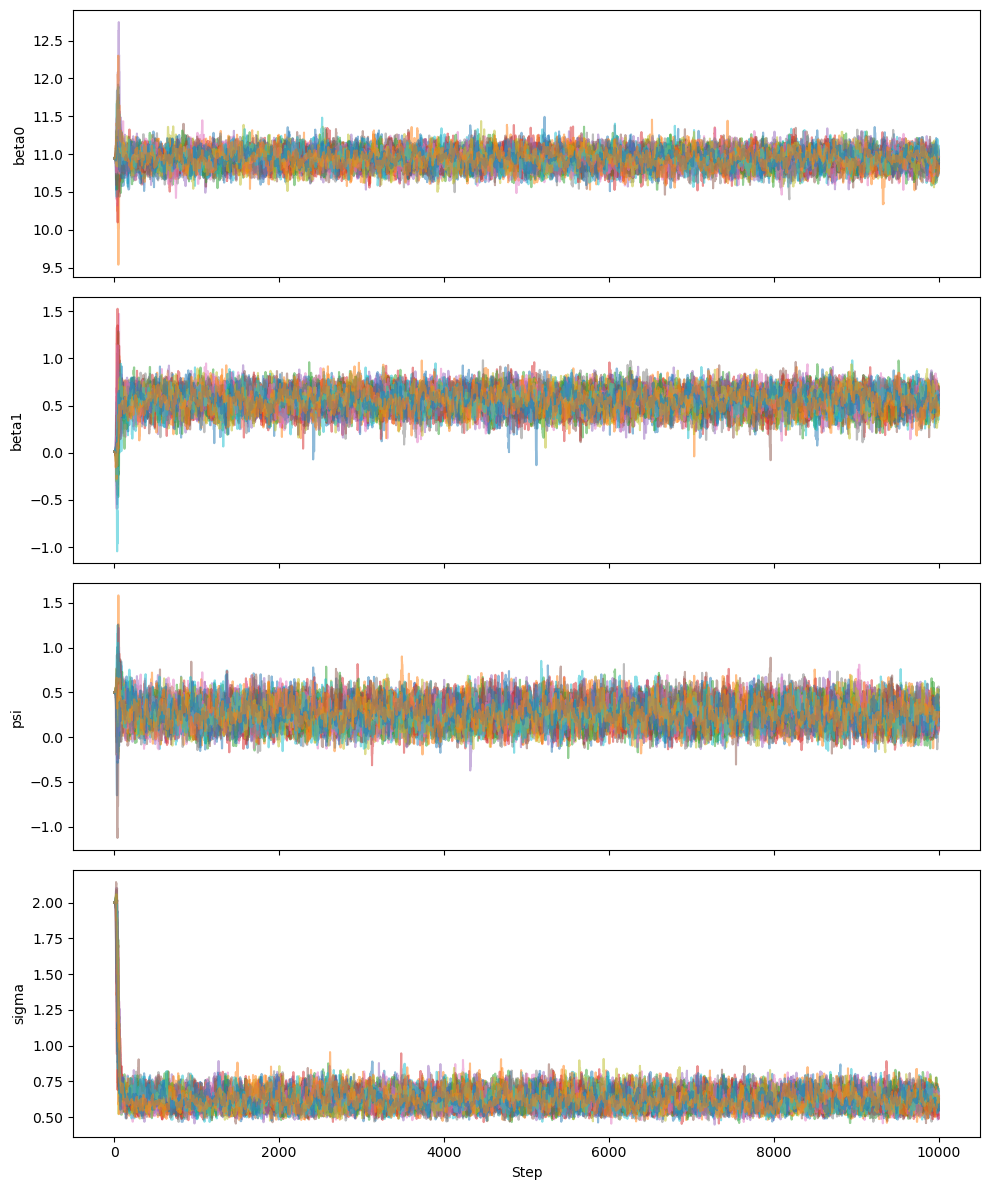

In [149]:
# ==========================================================
# TRACE PLOTS
# ==========================================================

chains = sampler.get_chain()

fig, axes = plt.subplots(ndim, figsize=(10,12), sharex=True)

for i in range(ndim):

    axes[i].plot(chains[:, :, i], alpha=0.5)

    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Step")

plt.tight_layout()
plt.show()

### The r hat and ESS checks

In [10]:
### R_hat check

idata = az.from_emcee(
    sampler,
    var_names=[
       "beta0",
        "beta1",
        "phi",
        "sigma"
    ]
)
print("\nR-hat:\n")

print(az.rhat(idata))


# ESS


print("\nESS:\n")

print(az.ess(idata))


R-hat:

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    beta0    float64 8B 1.006
    beta1    float64 8B 1.004
    phi      float64 8B 1.005
    sigma    float64 8B 1.004
Attributes:
    created_at:                 2026-05-28T14:45:07.879219+00:00
    arviz_version:              0.23.4
    inference_library:          emcee
    inference_library_version:  3.1.6

ESS:

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    beta0    float64 8B 6.576e+03
    beta1    float64 8B 6.301e+03
    phi      float64 8B 6.749e+03
    sigma    float64 8B 6.082e+03
Attributes:
    created_at:                 2026-05-28T14:45:07.879219+00:00
    arviz_version:              0.23.4
    inference_library:          emcee
    inference_library_version:  3.1.6


## Plot the parameter posterior

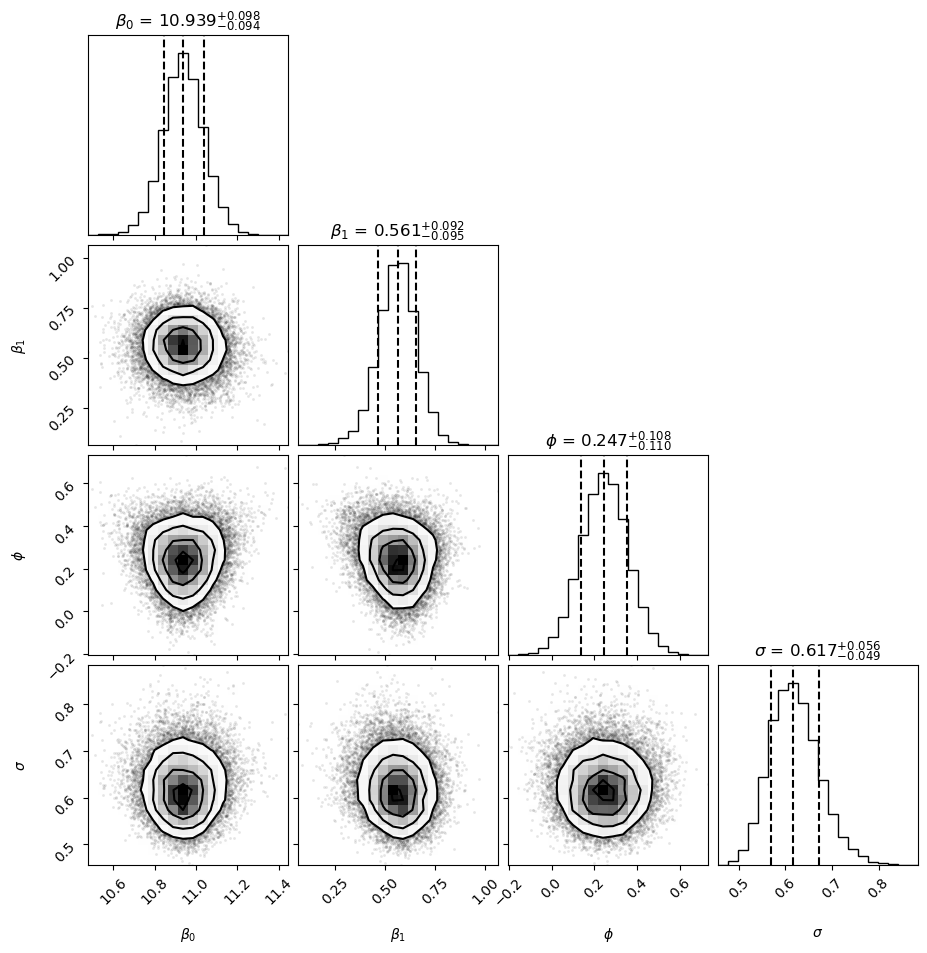

In [11]:
import corner
flat_samples = sampler.get_chain(discard=2000, thin=10, flat=True)

# Convert psi -> phi
flat_samples[:, 2] = np.tanh(flat_samples[:, 2])

# Parameter labels
labels = [r"$\beta_0$",
          r"$\beta_1$",
          
          r"$\phi$",
          r"$\sigma$"]

# Corner plot
fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    truths=None
)

plt.show()

## Calculate the warming trend from the normalized time axis

In [ ]:
### Warming trend
beta_1=0.564/time_std
print(beta_1)
error=0.131/time_std
print(error)
### Warming tre

0.026052360014102553
0.006051168726679849


## Plot the model vs fit

[10.93970072  0.55834952  0.24657722  0.62078961]


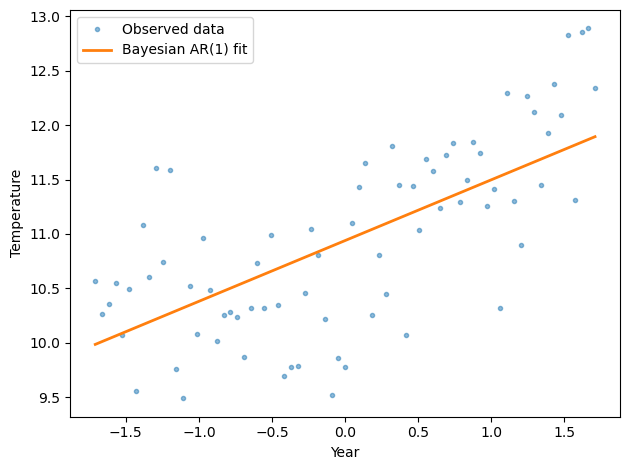

In [12]:
theta=np.mean(flat_samples,axis=0)
print(theta)
best_model=climate_model(theta,time_norm)
plt.plot(time_norm,t2m_trend_1year_values,".",alpha=0.5,label="Observed data")

plt.plot(
    time_norm,
    best_model,
    linewidth=2,
    label="Bayesian AR(1) fit"
)

plt.xlabel("Year")
plt.ylabel("Temperature")
plt.legend()

plt.tight_layout()
plt.show()

# Bayesian Code with AR(1) on monthly temperature data
Here we do not subtract seasonal component but fit for it with 4 harmonic functions.

In [163]:
from Model_A import climate_model_harmonics,log_probability_harmonics,log_likelihood_harmonics

## Data processing

In [ ]:
removed_seasonal=t2m_p-temp_seasonal
t2m_trend_1year = removed_seasonal.resample({"valid_time": "1YE"}).mean()
time_trend_1year=pd.to_datetime(t2m_trend_1year["valid_time"].values)
t2m_trend_1year_values=t2m_trend_1year.values
time_trend_1year_values=(time_trend_1year.year).values

### Standardadize time axis

time_mean = time_trend_1year_values.mean()
time_std  = time_trend_1year_values.std()
time_norm = (time_trend_1year_values - time_mean) / time_std

In [23]:
#t2m_1year = t2m_p.resample({"valid_time": "1YE"}).mean()
t2m_values = t2m_p.values
time_series=pd.to_datetime(t2m_p["valid_time"].values)
time_series_cont=(time_series.year).values +time_series.month/12

### Standardadize time axis
time_series_mean =np.mean(time_series_cont)
time_series_std  = np.std(time_series_cont)
time_series_norm = (time_series_cont - time_series_mean) / time_series_std
time_series_harmonics=time_series_cont
time_series_trend=time_series_norm

In [ ]:
nharm = 4

# Parameters: beta0, bet1,a1 -- a4, b1--b4, psi, sigma

ndim = 2*nharm + 4

nwalkers = 64

# ==========================================================
# INITIAL PARAMETER VECTOR
# ==========================================================

initial = np.zeros(ndim)

# beta0
initial[0] = t2m_values.mean()

# beta1
initial[1] = 0.01

# psi
initial[-2] = 0.5

# sigma
initial[-1] = t2m_values.std()

# ==========================================================
# INITIALIZE WALKERS
# ==========================================================

pos = initial + 1e-4 * np.random.randn(
    nwalkers,
    ndim
)

# ==========================================================
# RUN THE SAMPLER
# ==========================================================

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability_harmonics,
    args=(
        time_series_trend,
        time_series_harmonics,
        t2m_values,
        nharm
    )
)

sampler.run_mcmc(
    pos,
    60000,
    progress=True
)

# ==========================================================
# EXTRACT SAMPLES
# ==========================================================

samples = sampler.get_chain(
    discard=5000,
    thin=10,
    flat=True
)

# ==========================================================
# CONVERT PSI -> PHI
# ==========================================================

samples[:, -2] = np.tanh(samples[:, -2])

# ==========================================================
# PARAMETER LABELS
# ==========================================================

labels = (
    ["beta0", "beta1"]
    + [f"a{k}" for k in range(1, nharm+1)]
    + [f"b{k}" for k in range(1, nharm+1)]
    + ["phi", "sigma"]
)

# ==========================================================
# PARAMETER ESTIMATES
# ==========================================================

print("\nPosterior parameter estimates:\n")

for i, label in enumerate(labels):

    q16, q50, q84 = np.percentile(
        samples[:, i],
        [16, 50, 84]
    )

    print(
        f"{label:8s} = "
        f"{q50:.4f} "
        f"(+{q84-q50:.4f}, "
        f"-{q50-q16:.4f})"
    )

You must install the tqdm library to use progress indicators with emcee



Posterior parameter estimates:

beta0    = 10.9487 (+0.0618, -0.0619)
beta1    = 0.5705 (+0.0607, -0.0605)
a1       = -6.2442 (+0.0849, -0.0842)
a2       = -0.3257 (+0.0792, -0.0791)
a3       = -0.0041 (+0.0737, -0.0732)
a4       = 0.0392 (+0.0692, -0.0696)
b1       = -4.4137 (+0.0851, -0.0846)
b2       = 0.4866 (+0.0791, -0.0796)
b3       = -0.0297 (+0.0744, -0.0742)
b4       = 0.0609 (+0.0692, -0.0694)
phi      = 0.1435 (+0.0327, -0.0325)
sigma    = 1.5899 (+0.0381, -0.0369)


## Run Diagonistics


R-hat:

<xarray.Dataset> Size: 96B
Dimensions:  ()
Data variables:
    beta0    float64 8B 1.003
    beta1    float64 8B 1.002
    a1       float64 8B 1.002
    a2       float64 8B 1.003
    a3       float64 8B 1.003
    a4       float64 8B 1.003
    b1       float64 8B 1.003
    b2       float64 8B 1.002
    b3       float64 8B 1.002
    b4       float64 8B 1.003
    phi      float64 8B 1.003
    sigma    float64 8B 1.003
Attributes:
    created_at:                 2026-05-29T19:57:16.410918+00:00
    arviz_version:              0.23.4
    inference_library:          emcee
    inference_library_version:  3.1.6

ESS:

<xarray.Dataset> Size: 96B
Dimensions:  ()
Data variables:
    beta0    float64 8B 2.348e+04
    beta1    float64 8B 2.453e+04
    a1       float64 8B 2.584e+04
    a2       float64 8B 2.37e+04
    a3       float64 8B 1.836e+04
    a4       float64 8B 2.483e+04
    b1       float64 8B 2.119e+04
    b2       float64 8B 2.555e+04
    b3       float64 8B 2.549e+04
    b4   

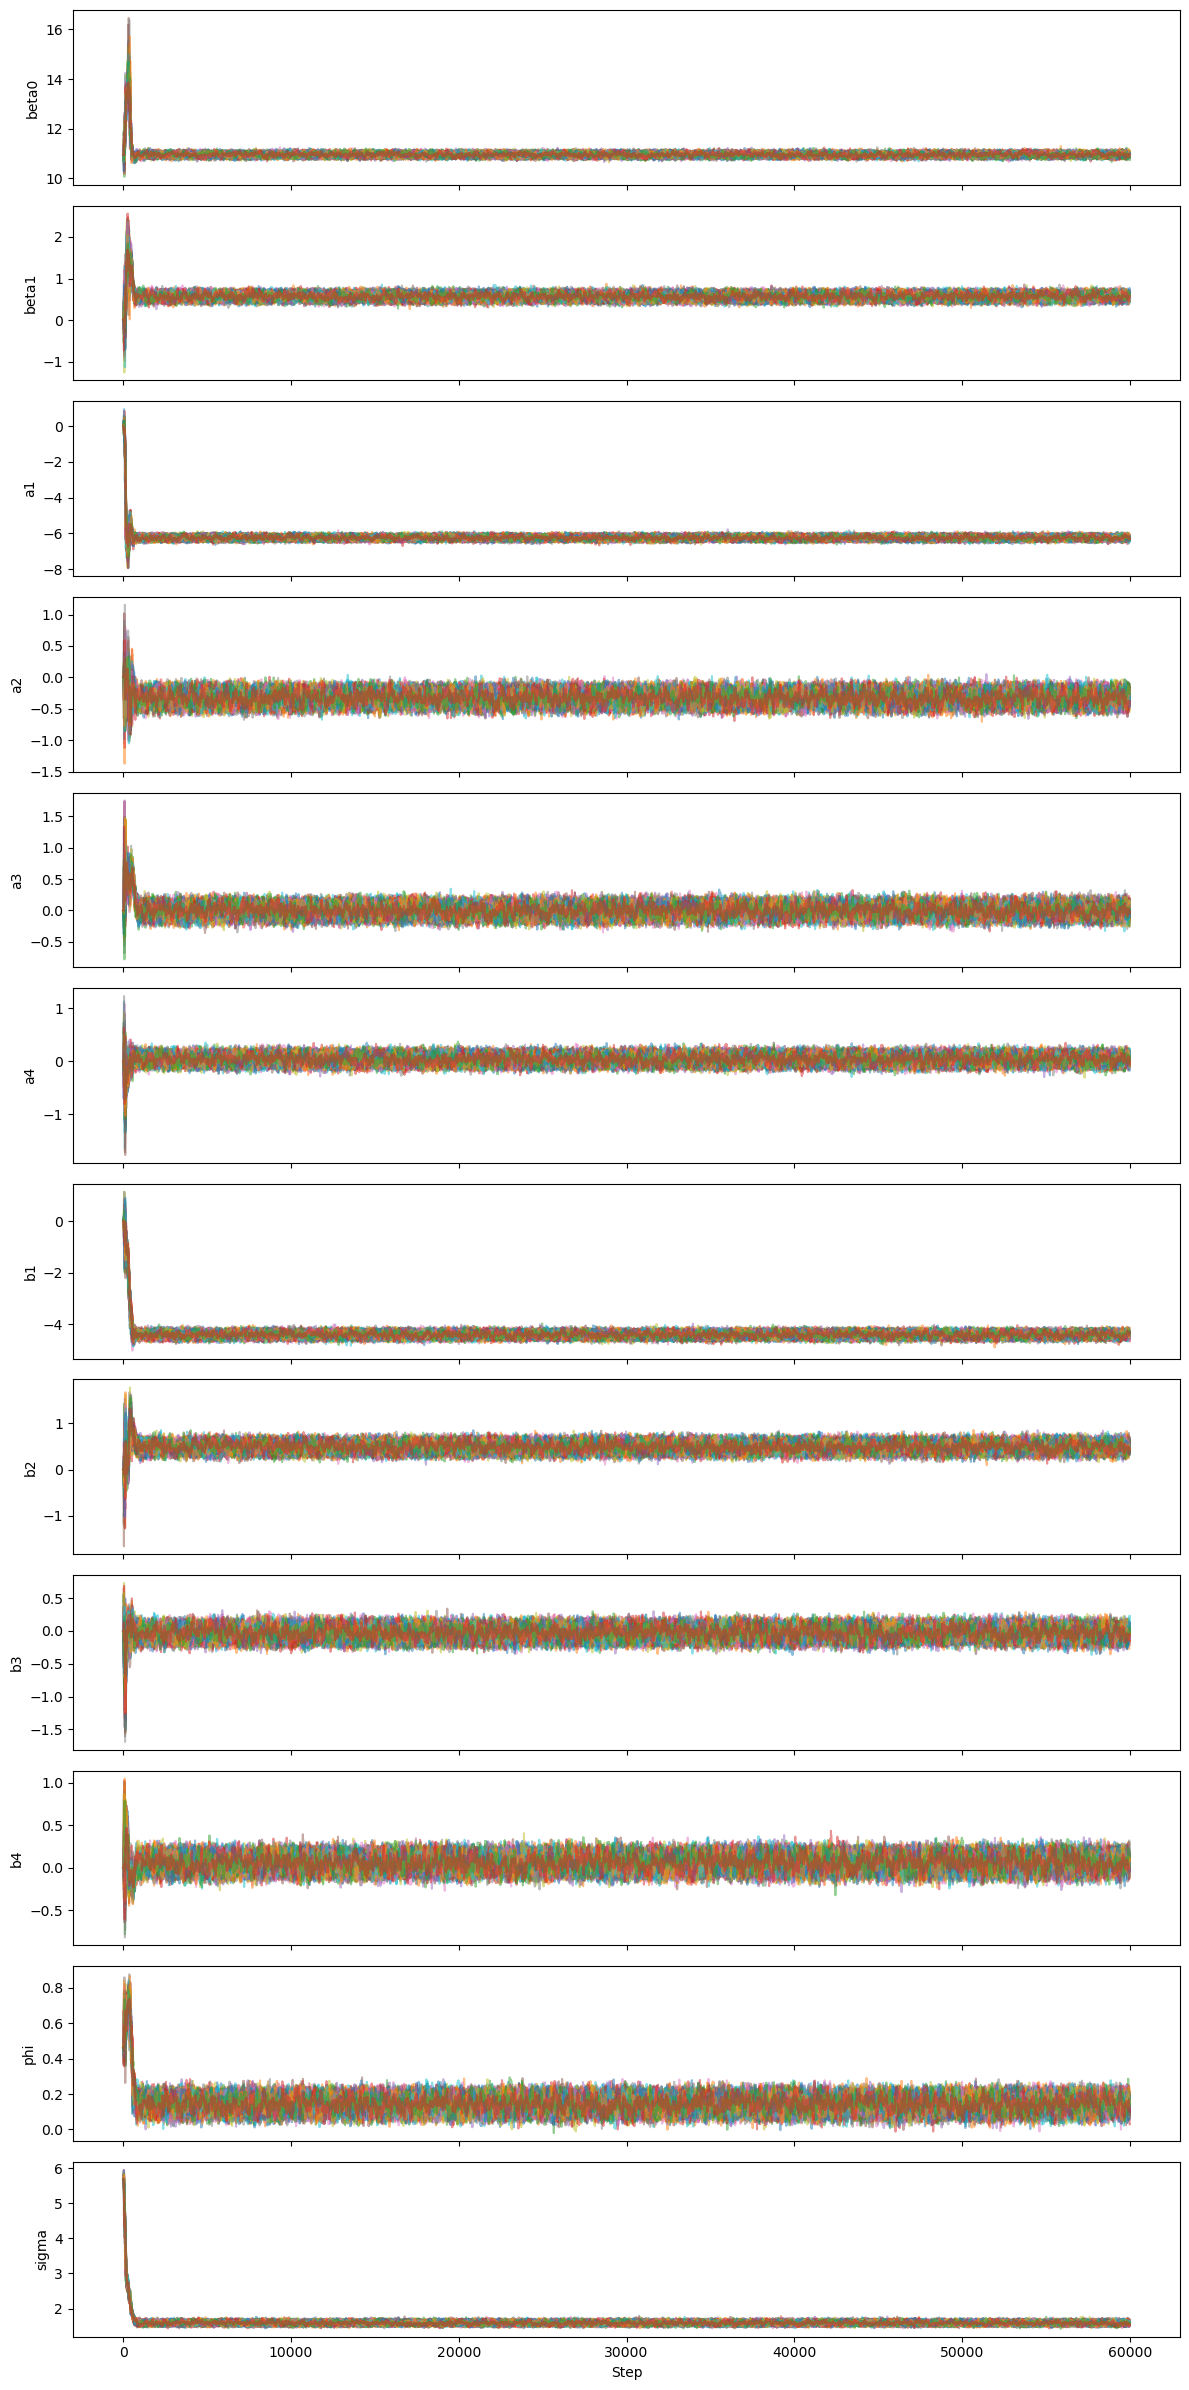


Autocorrelation times:

beta0    : 313.16
beta1    : 187.38
a1       : 160.79
a2       : 160.92
a3       : 342.26
a4       : 150.90
b1       : 403.64
b2       : 120.05
b3       : 143.49
b4       : 131.27
phi      : 441.22
sigma    : 347.15


In [27]:

labels = (
    ["beta0", "beta1"]
    + [f"a{k}" for k in range(1, nharm+1)]
    + [f"b{k}" for k in range(1, nharm+1)]
    + ["psi", "sigma"]
)

chains = sampler.get_chain()

chains[:, :, -2] = np.tanh(chains[:, :, -2])

labels[-2] = "phi"

idata = az.from_emcee(
    sampler,
    var_names=labels
)

print("\nR-hat:\n")

print(
    az.rhat(idata)
)

print("\nESS:\n")

print(
    az.ess(idata)
)

fig, axes = plt.subplots(
    ndim,
    figsize=(12, 2*ndim),
    sharex=True
)

for i in range(ndim):

    axes[i].plot(
        chains[:, :, i],
        alpha=0.5
    )

    axes[i].set_ylabel(labels[i])

axes[-1].set_xlabel("Step")

plt.tight_layout()

plt.show()

print("\nAutocorrelation times:\n")

tau = sampler.get_autocorr_time()

for i, label in enumerate(labels):

    print(
        f"{label:8s} : {tau[i]:.2f}"
    )


## Corner plots for all parameters

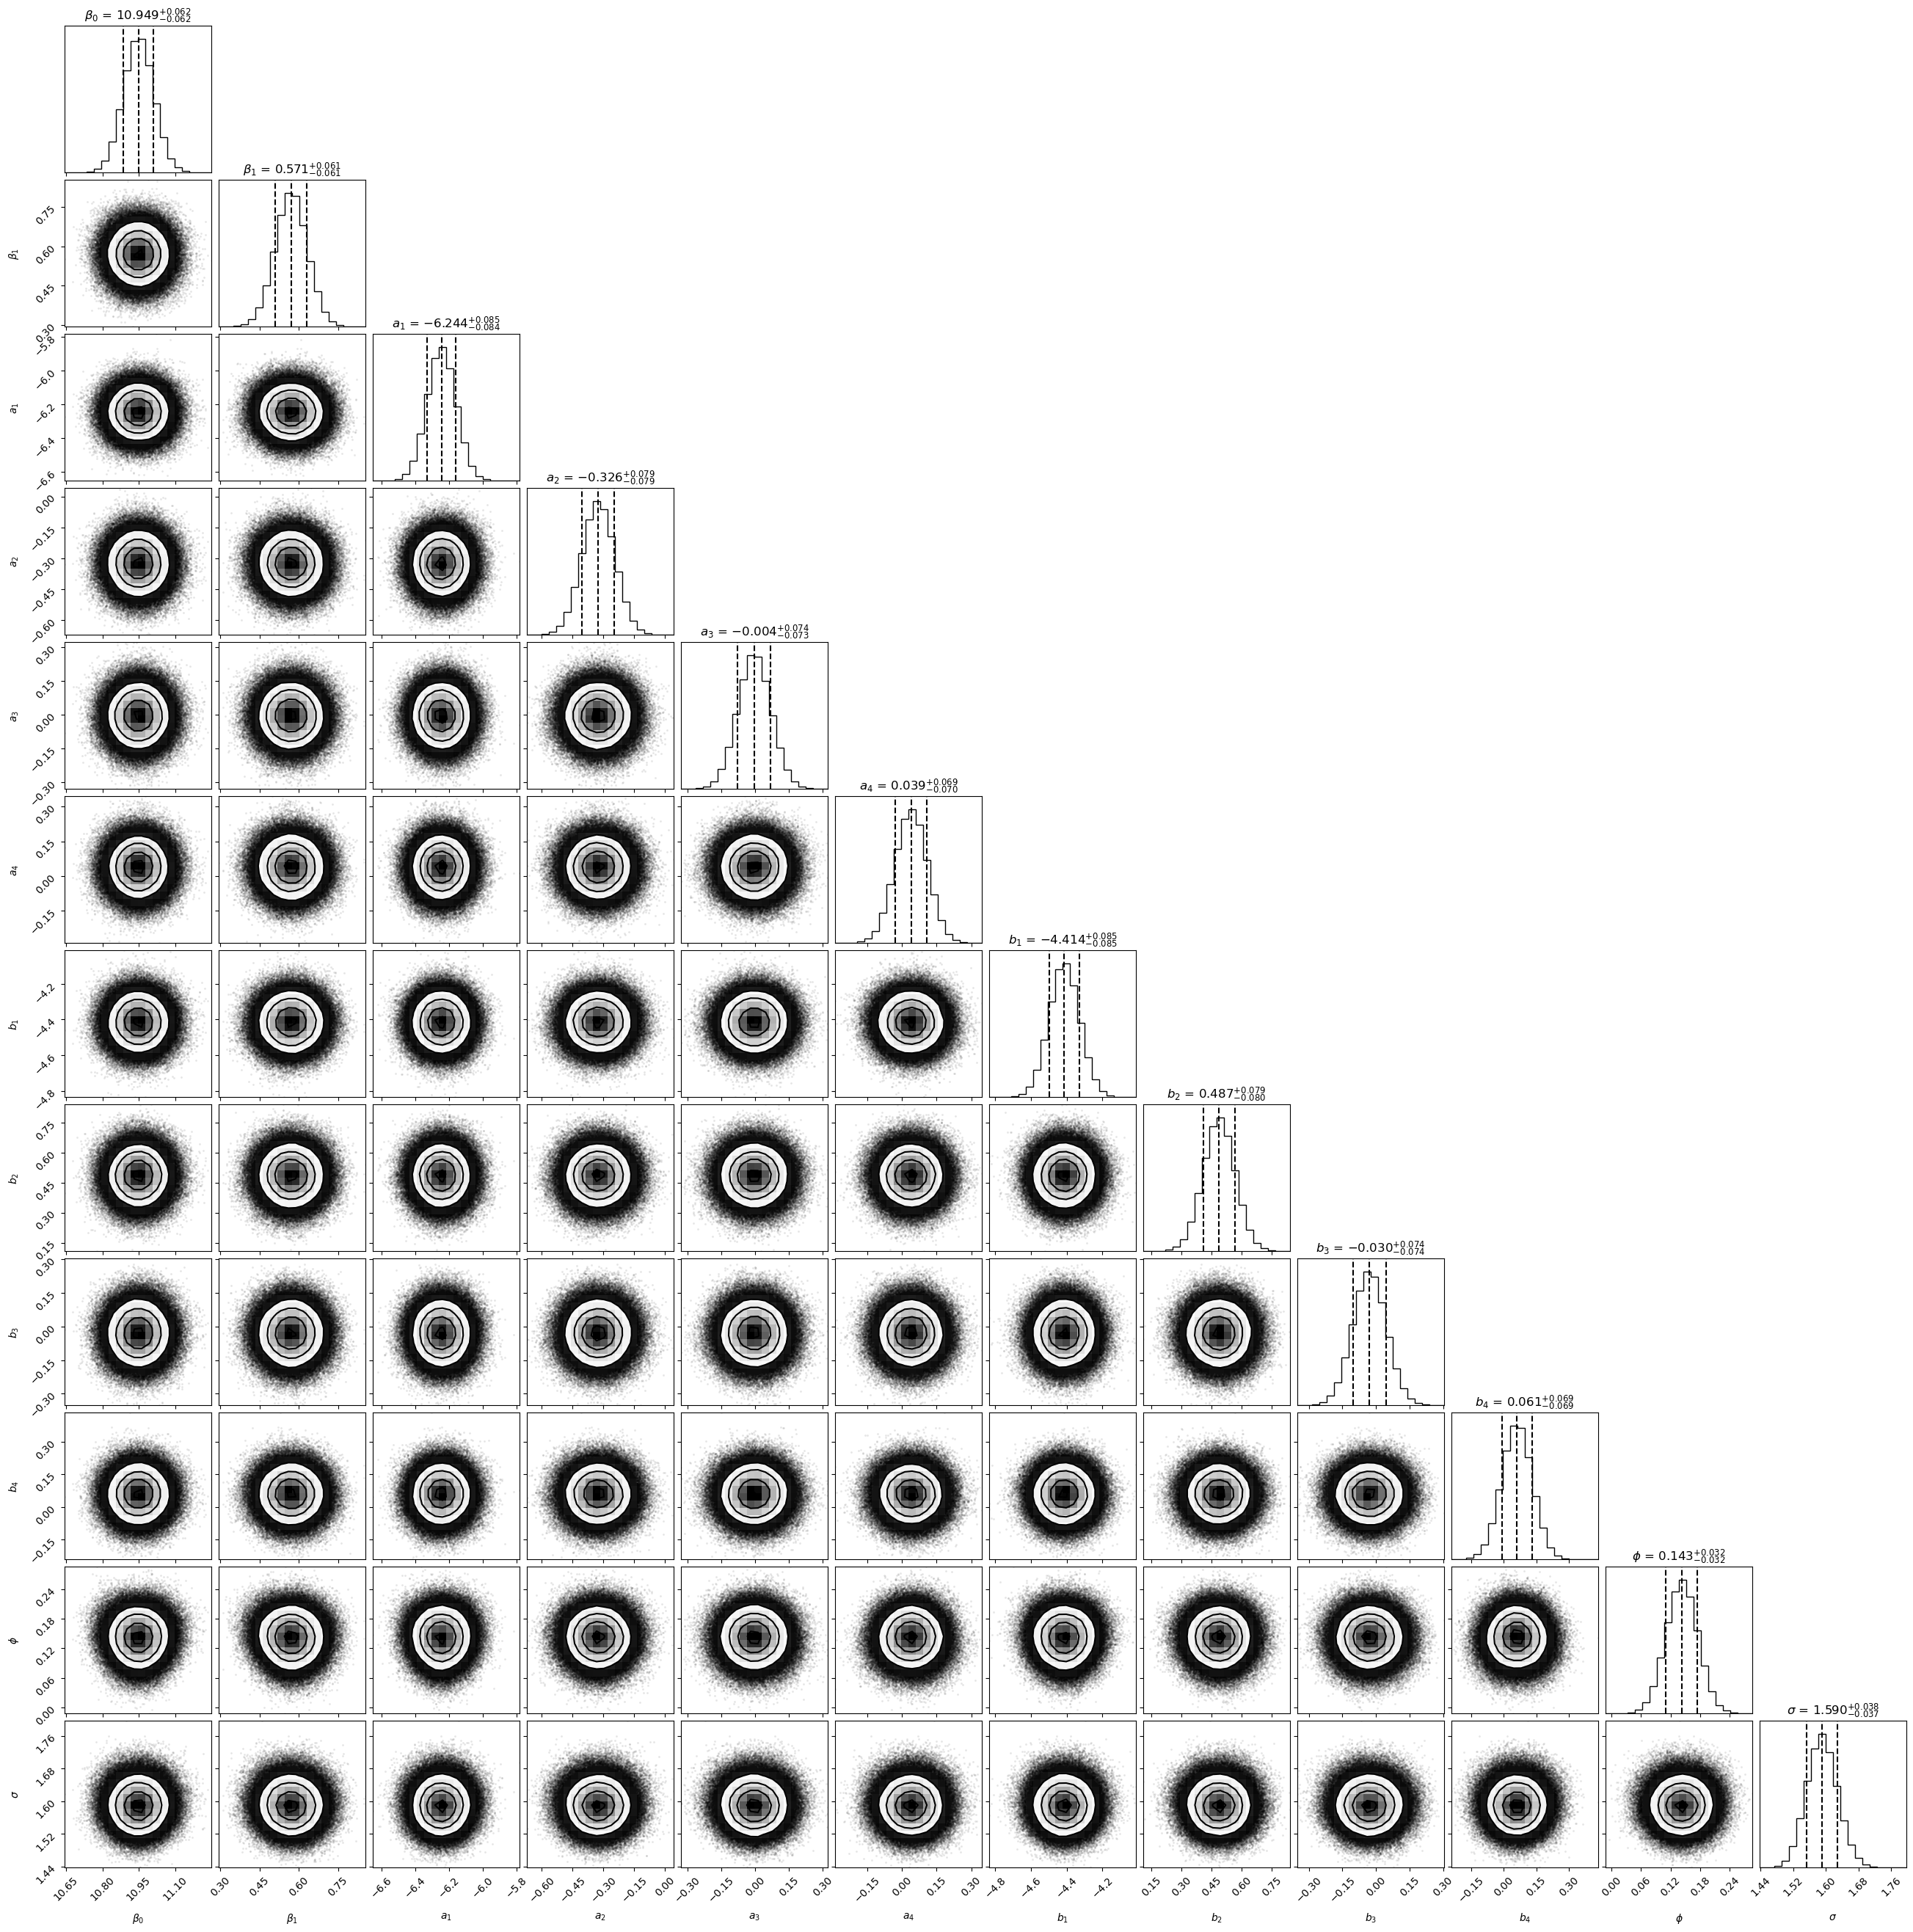

In [28]:
flat_samples = sampler.get_chain(
    discard=5000,
    thin=10,
    flat=True
)

flat_samples[:, -2] = np.tanh(
    flat_samples[:, -2]
)

labels = (
    [r"$\beta_0$", r"$\beta_1$"]
    + [rf"$a_{k}$" for k in range(1, nharm+1)]
    + [rf"$b_{k}$" for k in range(1, nharm+1)]
    + [r"$\phi$", r"$\sigma$"]
)

fig = corner.corner(
    flat_samples,
    labels=labels,
    show_titles=True,
    title_fmt=".3f",
    quantiles=[0.16, 0.5, 0.84],
    truths=None
)

plt.show()

## Plot Model and fit


[ 1.13633098e+01  5.41359583e-01 -6.24346268e+00 -3.25210986e-01
 -5.37181001e-03  3.91468174e-02 -4.41925369e+00  4.89681985e-01
 -2.82492672e-02  6.08343121e-02  1.69344064e-01  1.61334908e+00]


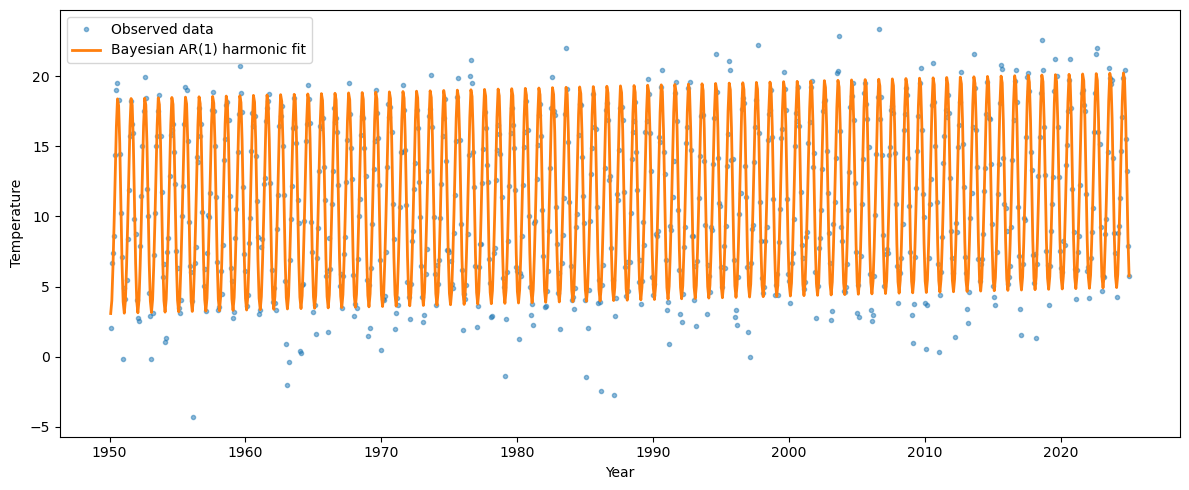

In [182]:
theta = np.mean(
    flat_samples,
    axis=0
)

theta[-2] = np.tanh(theta[-2])

print(theta)

best_model = climate_model_harmonics(
    theta,
    time_series_trend,
    time_series_harmonics,
    nharm
)

plt.figure(figsize=(12,5))

plt.plot(
    time_series_harmonics,
    t2m_values,
    ".",
    alpha=0.5,
    label="Observed data"
)

plt.plot(
    time_series_harmonics,
    best_model,
    linewidth=2,
    label="Bayesian AR(1) harmonic fit"
)

plt.xlabel("Year")

plt.ylabel("Temperature")

plt.legend()

plt.tight_layout()

plt.show()

# Fitting for annual maximum temeprature

In [18]:
# Annual maximum temperature
t2m_annual_max = t2m_p.groupby('valid_time.year').max(dim='valid_time')
anual_max=t2m_annual_max.values

## Run the Bayesian code

In [20]:
## Define the number of walkers and initial parameters
ndim = 4
nwalkers = 32

initial = np.array([
    t2m_trend_1year_values.mean(),   # beta0
    0.01,          # beta1
    0.5,           # psi
    2.0            # sigma
])

# Initialize walkers
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

## Run the Sampler

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_probability,
    args=(time_norm, anual_max)
)

sampler.run_mcmc(pos, 10000, progress=True)

## Extract samples

samples = sampler.get_chain(
    discard=2000,
    thin=10,
    flat=True
)

## Parameter estimates from chain

labels = [
    "beta0",
    "beta1",
    "psi",
    "sigma"
]

print("\nPosterior parameter estimates:\n")

for i, label in enumerate(labels):

    q16, q50, q84 = np.percentile(
        samples[:, i],
        [16, 50, 84]
    )

    print(
        f"{label:8s} = "
        f"{q50:.4f} "
        f"(+{q84-q50:.4f}, -{q50-q16:.4f})")

You must install the tqdm library to use progress indicators with emcee



Posterior parameter estimates:

beta0    = 19.3619 (+0.1349, -0.1361)
beta1    = 0.6958 (+0.1224, -0.1278)
psi      = -0.1545 (+0.1134, -0.1134)
sigma    = 1.3199 (+0.1210, -0.1063)


In [21]:
idata = az.from_emcee(
    sampler,
    var_names=[
       "beta0",
        "beta1",
        "phi",
        "sigma"
    ]
)
print("\nR-hat:\n")

print(az.rhat(idata))


# ESS


print("\nESS:\n")

print(az.ess(idata))


R-hat:

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    beta0    float64 8B 1.007
    beta1    float64 8B 1.004
    phi      float64 8B 1.007
    sigma    float64 8B 1.006
Attributes:
    created_at:                 2026-05-28T15:38:11.611682+00:00
    arviz_version:              0.23.4
    inference_library:          emcee
    inference_library_version:  3.1.6

ESS:

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    beta0    float64 8B 4.91e+03
    beta1    float64 8B 5.487e+03
    phi      float64 8B 4.454e+03
    sigma    float64 8B 4.541e+03
Attributes:
    created_at:                 2026-05-28T15:38:11.611682+00:00
    arviz_version:              0.23.4
    inference_library:          emcee
    inference_library_version:  3.1.6


## Warming trend per year

In [34]:
trend_b1= np.percentile(samples[:, 1],  50)
beta_1_yearly=trend_b1/time_std
print(beta_1_yearly)
error=0.131/time_std
print(r"Warming trend per year in Paris is: %.4f $\pm$ %.4f"%(trend_b1,error))

0.02635418693786214
Warming trend per year in Paris is: 0.5705 $\pm$ 0.0061


In [36]:
theta = [1.0, 2.0, 0.5, 1.0]
t = np.array([0, 1, 2])

result = climate_model(theta, t)

expected = theta[0]+theta[1]*t

np.testing.assert_allclose(result, expected)

In [37]:
expected

array([1., 3., 5.])

In [38]:
result

array([1., 3., 5.])